# AI-Powered Retail Demand Forecasting and Inventory Optimization

## Notebook 02 — Data Cleaning and Validation

### Objective

The objective of this notebook is to clean, validate, and prepare the raw retail
dataset for subsequent feature engineering and machine learning.

The notebook will:

- Load the original raw dataset
- Validate data types
- Check duplicate records
- Validate categorical values
- Check numerical ranges
- Investigate outliers
- Validate the target variable
- Validate temporal ordering
- Save a cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = "../data/raw/sales_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (76000, 16)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [3]:
clean_df = df.copy()

print("Working copy created.")

Working copy created.


In [4]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [5]:
clean_df["Date"] = pd.to_datetime(
    clean_df["Date"],
    errors="coerce"
)

print(clean_df["Date"].dtype)

datetime64[ns]


In [6]:
invalid_dates = clean_df["Date"].isna().sum()

print(f"Invalid dates: {invalid_dates}")

Invalid dates: 0


In [7]:
missing_summary = pd.DataFrame({
    "Missing Count": clean_df.isna().sum(),
    "Missing Percentage": (
        clean_df.isna().sum() / len(clean_df) * 100
    )
})

missing_summary

,Missing Count,Missing Percentage
Date,0,0.0
Store ID,0,0.0
Product ID,0,0.0
Category,0,0.0
Region,0,0.0
Inventory Level,0,0.0
Units Sold,0,0.0
Units Ordered,0,0.0
Price,0,0.0
Discount,0,0.0


In [8]:
duplicate_count = clean_df.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_count}")

Exact duplicate rows: 0


In [9]:
if duplicate_count > 0:
    clean_df = clean_df.drop_duplicates().reset_index(drop=True)

print(f"Shape after duplicate removal: {clean_df.shape}")

Shape after duplicate removal: (76000, 16)


In [10]:
key_columns = [
    "Date",
    "Store ID",
    "Product ID"
]

key_duplicates = clean_df.duplicated(
    subset=key_columns
).sum()

print(
    f"Duplicate Date + Store + Product records: "
    f"{key_duplicates}"
)

Duplicate Date + Store + Product records: 0


In [11]:
if key_duplicates > 0:
    duplicate_records = clean_df[
        clean_df.duplicated(
            subset=key_columns,
            keep=False
        )
    ].sort_values(key_columns)

    display(duplicate_records.head(20))
else:
    print("No duplicate Date-Store-Product combinations found.")

No duplicate Date-Store-Product combinations found.


In [31]:
categorical_columns = [
    "Category",
    "Region",
    "Weather Condition",
    "Promotion",
    "Seasonality",
    "Epidemic"
]

for column in categorical_columns:
    print(f"\n{'=' * 50}")
    print(column)
    print(clean_df[column].value_counts(dropna=False))


Category
Category
Groceries      30400
Furniture      13680
Clothing       12160
Toys           10640
Electronics     9120
Name: count, dtype: int64

Region
Region
North    30400
South    15200
East     15200
West     15200
Name: count, dtype: int64

Weather Condition
Weather Condition
Cloudy    24360
Sunny     22980
Rainy     17500
Snowy     11160
Name: count, dtype: int64

Promotion
Promotion
0    51000
1    25000
Name: count, dtype: int64

Seasonality
Seasonality
Winter    21000
Spring    18400
Summer    18400
Autumn    18200
Name: count, dtype: int64

Epidemic
Epidemic
0    60800
1    15200
Name: count, dtype: int64


In [12]:
numerical_columns = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Demand"
]

clean_df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Inventory Level,76000.0,301.062842,226.510161,0.00,136.0000,227.0,408.0000,2267.00
Units Sold,76000.0,88.827316,43.994525,0.00,58.0000,84.0,114.0000,426.00
Units Ordered,76000.0,89.090645,162.404627,0.00,0.0000,0.0,121.0000,1616.00
Price,76000.0,67.726028,39.377899,4.74,31.9975,64.5,95.8300,228.03
Discount,76000.0,9.087039,7.475781,0.00,5.0000,10.0,10.0000,25.00
Competitor Pricing,76000.0,69.454029,40.943818,4.29,32.6200,65.7,97.9325,261.22
Demand,76000.0,104.317158,46.964801,4.00,71.0000,100.0,133.0000,430.00


In [13]:
negative_summary = {}

for column in numerical_columns:
    negative_summary[column] = (
        clean_df[column] < 0
    ).sum()

negative_summary = pd.Series(negative_summary)

negative_summary

Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Competitor Pricing    0
Demand                0
dtype: int64

In [14]:
zero_summary = {}

for column in numerical_columns:
    zero_summary[column] = (
        clean_df[column] == 0
    ).sum()

zero_summary = pd.Series(zero_summary)

zero_summary

Inventory Level         406
Units Sold              406
Units Ordered         47107
Price                     0
Discount              17126
Competitor Pricing        0
Demand                    0
dtype: int64

In [15]:
print("Invalid Price records:")

display(
    clean_df[clean_df["Price"] <= 0]
)

Invalid Price records:


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand


In [16]:
invalid_price = (
    clean_df["Price"] <= 0
).sum()

print(f"Records with non-positive price: {invalid_price}")

Records with non-positive price: 0


In [17]:
print(
    clean_df["Discount"].describe()
)

count    76000.000000
mean         9.087039
std          7.475781
min          0.000000
25%          5.000000
50%         10.000000
75%         10.000000
max         25.000000
Name: Discount, dtype: float64


In [18]:
print(
    f"Discount < 0: {(clean_df['Discount'] < 0).sum()}"
)

print(
    f"Discount > 1: {(clean_df['Discount'] > 1).sum()}"
)

Discount < 0: 0
Discount > 1: 58874


In [19]:
print("Demand statistics:")

display(
    clean_df["Demand"].describe()
)

Demand statistics:


count    76000.000000
mean       104.317158
std         46.964801
min          4.000000
25%         71.000000
50%        100.000000
75%        133.000000
max        430.000000
Name: Demand, dtype: float64

In [20]:
negative_demand = (
    clean_df["Demand"] < 0
).sum()

print(f"Negative demand records: {negative_demand}")

Negative demand records: 0


In [21]:
if negative_demand > 0:
    display(
        clean_df[
            clean_df["Demand"] < 0
        ]
    )

In [22]:
print(f"Minimum date: {clean_df['Date'].min()}")
print(f"Maximum date: {clean_df['Date'].max()}")
print(f"Unique dates: {clean_df['Date'].nunique()}")

Minimum date: 2022-01-01 00:00:00
Maximum date: 2024-01-30 00:00:00
Unique dates: 760


In [23]:
all_dates = pd.date_range(
    start=clean_df["Date"].min(),
    end=clean_df["Date"].max(),
    freq="D"
)

existing_dates = pd.DatetimeIndex(
    clean_df["Date"].unique()
)

missing_dates = all_dates.difference(existing_dates)

print(f"Expected dates: {len(all_dates)}")
print(f"Actual dates: {len(existing_dates)}")
print(f"Missing dates: {len(missing_dates)}")

if len(missing_dates) > 0:
    print("\nFirst missing dates:")
    print(missing_dates[:20])

Expected dates: 760
Actual dates: 760
Missing dates: 0


In [24]:
clean_df = clean_df.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

clean_df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-02,S001,P0001,Electronics,North,93,71,0,65.63,5,Snowy,0,73.66,Winter,0,84
2,2022-01-03,S001,P0001,Electronics,North,274,142,229,68.55,15,Snowy,1,80.73,Winter,0,132
3,2022-01-04,S001,P0001,Electronics,North,132,42,0,61.66,10,Snowy,0,54.88,Winter,0,67
4,2022-01-05,S001,P0001,Electronics,North,319,129,0,59.56,25,Snowy,1,57.34,Winter,0,110


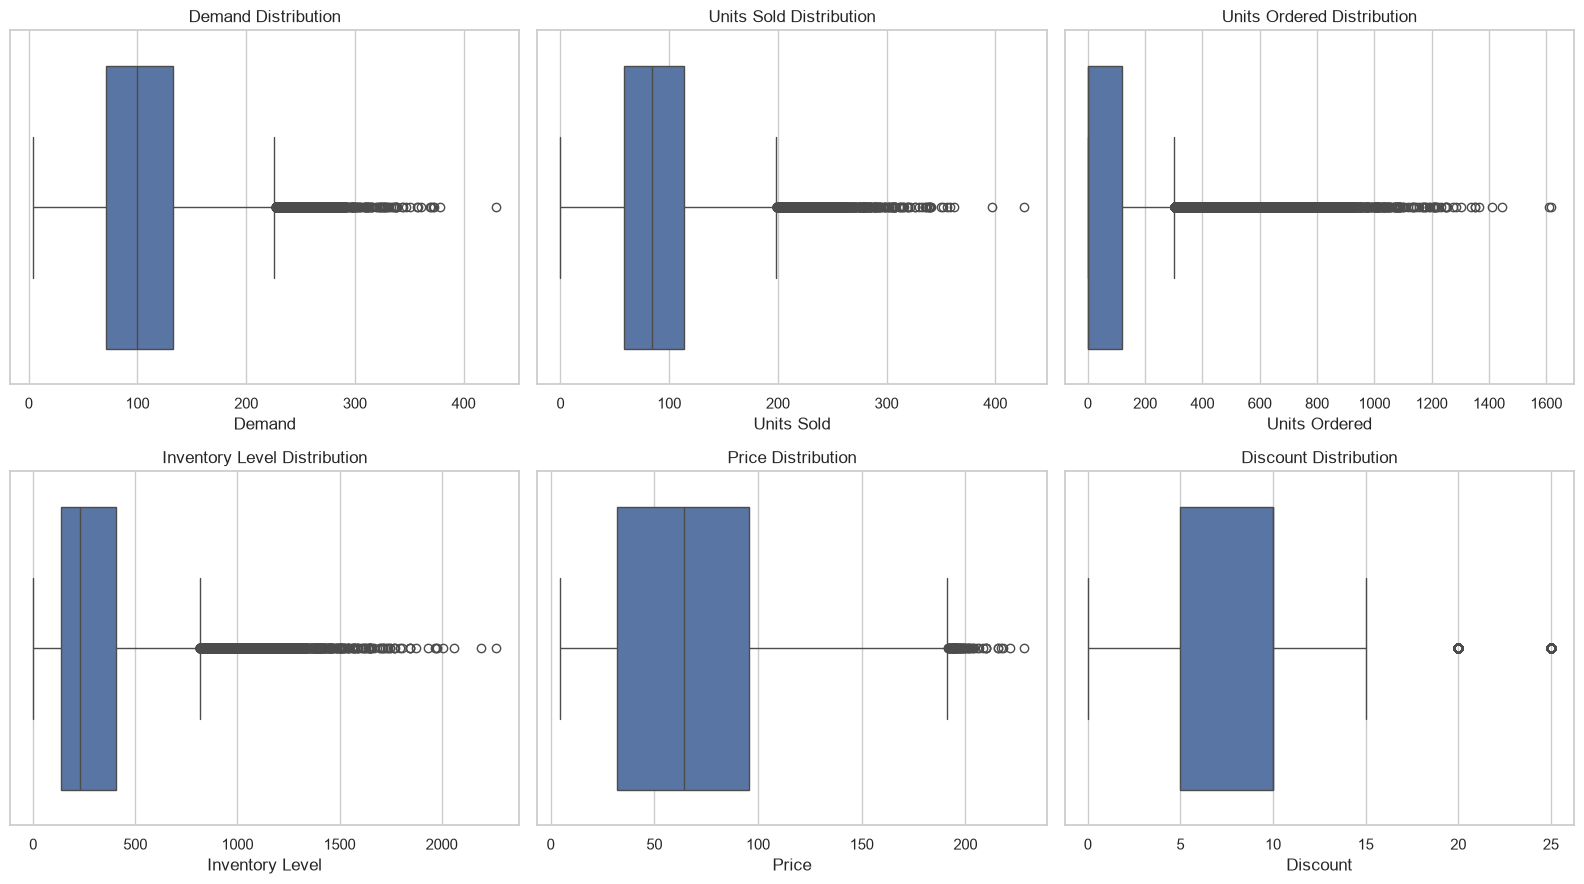

In [25]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 9)
)

outlier_columns = [
    "Demand",
    "Units Sold",
    "Units Ordered",
    "Inventory Level",
    "Price",
    "Discount"
]

for ax, column in zip(
    axes.flatten(),
    outlier_columns
):
    sns.boxplot(
        x=clean_df[column],
        ax=ax
    )
    ax.set_title(f"{column} Distribution")

plt.tight_layout()
plt.show()

In [26]:
outlier_summary = []

for column in numerical_columns:

    Q1 = clean_df[column].quantile(0.25)
    Q3 = clean_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (clean_df[column] < lower_bound) |
        (clean_df[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outliers,
        "Outlier %": outliers / len(clean_df) * 100
    })

outlier_summary = pd.DataFrame(
    outlier_summary
)

outlier_summary

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Inventory Level,136.0000,408.0000,272.0000,-272.00000,816.00000,2759,3.630263
1,Units Sold,58.0000,114.0000,56.0000,-26.00000,198.00000,1411,1.856579
2,Units Ordered,0.0000,121.0000,121.0000,-181.50000,302.50000,7524,9.900000
3,Price,31.9975,95.8300,63.8325,-63.75125,191.57875,70,0.092105
4,Discount,5.0000,10.0000,5.0000,-2.50000,17.50000,12413,16.332895
5,Competitor Pricing,32.6200,97.9325,65.3125,-65.34875,195.90125,185,0.243421
6,Demand,71.0000,133.0000,62.0000,-22.00000,226.00000,986,1.297368


In [27]:
print(
    f"Unique stores: {clean_df['Store ID'].nunique()}"
)

print(
    f"Unique products: {clean_df['Product ID'].nunique()}"
)

Unique stores: 5
Unique products: 20


In [29]:
print(
    "Missing Store IDs:",
    clean_df["Store ID"].isna().sum()
)

print(
    "Missing Product IDs:",
    clean_df["Product ID"].isna().sum()
)

Missing Store IDs: 0
Missing Product IDs: 0


In [32]:
for column in categorical_columns:
    print(
        f"{column}: "
        f"{clean_df[column].nunique()} unique values"
    )

Category: 5 unique values
Region: 4 unique values
Weather Condition: 4 unique values
Promotion: 2 unique values
Seasonality: 4 unique values
Epidemic: 2 unique values


In [33]:
final_missing = clean_df.isna().sum()

final_missing[final_missing > 0]

Series([], dtype: int64)

In [34]:
print("FINAL DATASET VALIDATION")
print("=" * 50)

print(f"Rows              : {len(clean_df):,}")
print(f"Columns           : {len(clean_df.columns)}")
print(f"Missing values    : {clean_df.isna().sum().sum():,}")
print(f"Duplicate rows    : {clean_df.duplicated().sum():,}")
print(f"Unique stores     : {clean_df['Store ID'].nunique():,}")
print(f"Unique products   : {clean_df['Product ID'].nunique():,}")
print(f"Unique dates      : {clean_df['Date'].nunique():,}")
print(f"Minimum date      : {clean_df['Date'].min()}")
print(f"Maximum date      : {clean_df['Date'].max()}")

FINAL DATASET VALIDATION
Rows              : 76,000
Columns           : 16
Missing values    : 0
Duplicate rows    : 0
Unique stores     : 5
Unique products   : 20
Unique dates      : 760
Minimum date      : 2022-01-01 00:00:00
Maximum date      : 2024-01-30 00:00:00


In [35]:
import os

os.makedirs(
    "../data/processed",
    exist_ok=True
)

In [36]:
OUTPUT_PATH = "../data/processed/cleaned_sales_data.csv"

clean_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(
    f"Cleaned dataset saved to:\n{OUTPUT_PATH}"
)

Cleaned dataset saved to:
../data/processed/cleaned_sales_data.csv


In [37]:
check_df = pd.read_csv(
    OUTPUT_PATH
)

print(
    f"Saved dataset shape: {check_df.shape}"
)

check_df.head()

Saved dataset shape: (76000, 16)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-02,S001,P0001,Electronics,North,93,71,0,65.63,5,Snowy,0,73.66,Winter,0,84
2,2022-01-03,S001,P0001,Electronics,North,274,142,229,68.55,15,Snowy,1,80.73,Winter,0,132
3,2022-01-04,S001,P0001,Electronics,North,132,42,0,61.66,10,Snowy,0,54.88,Winter,0,67
4,2022-01-05,S001,P0001,Electronics,North,319,129,0,59.56,25,Snowy,1,57.34,Winter,0,110


# Conclusion

The raw retail dataset has been inspected and prepared for the next stage of
the project.

The cleaning process focused on:

- Correcting the date data type
- Identifying missing values
- Identifying duplicate records
- Checking Date-Store-Product uniqueness
- Validating categorical variables
- Checking numerical ranges
- Investigating outliers
- Validating the demand target
- Validating the temporal range
- Sorting observations chronologically within each store-product combination

The cleaned dataset has been saved as:

`data/processed/cleaned_sales_data.csv`

### Next Notebook

The next stage is **Notebook 03 — Exploratory Data Analysis (EDA)**.

The EDA will focus specifically on discovering demand patterns that will guide
our feature engineering and model selection, including:

- Store-level demand patterns
- Product-level demand patterns
- Seasonality
- Trends
- Promotions
- Price effects
- Inventory-demand relationships
- Regional behaviour
- Demand volatility
- Time-series characteristics